In [1]:
from analyzer import * 
import seaborn as sns 

sns.set_theme(
    style="whitegrid",
    context="paper",
) 
mm = MMStarResults(results_path='/home/yuna/workspace/HPA/evaluation/scored/humans/human_mc_per_question.json')

13 7
found Qwen3-8B-Base in /home/yuna/workspace/HPA/evaluation/scored/pretrained/_mmstar.jsonl
found Qwen3-VL-4B-Instruct in /home/yuna/workspace/HPA/evaluation/scored/pretrained//_mmstar_blind.jsonl
found Qwen3-VL-4B-Instruct in /home/yuna/workspace/HPA/evaluation/scored/pretrained//_mmstar_inst_blind.jsonl
found Qwen3-VL-4B-Instruct in /home/yuna/workspace/HPA/evaluation/scored/pretrained//_mmstar.jsonl
found llava-1.5-7b-hf in /home/yuna/workspace/HPA/evaluation/scored/pretrained//mmstar_blind.jsonl
found llava-1.5-7b-hf in /home/yuna/workspace/HPA/evaluation/scored/pretrained//mmstar.jsonl
found llava-1.5-7b-hf in /home/yuna/workspace/HPA/evaluation/scored/pretrained//mmstar_inst_blind.jsonl
found llava-v1.6-mistral-7b-hf in /home/yuna/workspace/HPA/evaluation/scored/pretrained//mmstar_blind.jsonl
found llava-v1.6-mistral-7b-hf in /home/yuna/workspace/HPA/evaluation/scored/pretrained//mmstar.jsonl
found llava-v1.6-mistral-7b-hf in /home/yuna/workspace/HPA/evaluation/scored/pretrai

In [ ]:
model_blind = mm.model_blind[mm.model_blind['condition'] == 'inst blind']

In [ ]:
from utils.quadrants import get_examples  
mms = pd.merge(
    pd.merge(mm.model_mg, model_blind, on=['model','finetuned', 'question_id', 'l2_category', 'category'], how='inner'), 
    mm.human.groupby(['question_id', 'l2_category', 'category']).mean(numeric_only=True).reset_index(),
    on=['question_id', 'l2_category', 'category'], 
    how='inner', 
    suffixes=("_model", "_human")
)

mms["human_correct"] = (mms["correct_human"] >= 50).astype(int)  
mms["model_correct"] = (mms["correct_model"] >= 50).astype(int) 
mms.groupby(['model', 'finetuned']).count()
mms["cc_quadrant"] = mms.apply(cc_quadrant, axis=1) 
mms['dataset'] = "MMStar"  
mms.groupby(['cc_quadrant'])['MG'].mean() 

AttributeError: 'MMStarResults' object has no attribute 'model_mg'

In [53]:
# For MMStar datset 
def get_examples(vqq, human_vqa, qid=None, verbose=True ): 

    vqq = vqq[vqq['model'].isin(['InternVL 3.5 (8B)', 'Qwen3‑VL (8B)', 'LLaVA‑Mistral (7B)'])]

    if qid is None: 
        qid = np.random.choice(vqq.question_id.unique()) 
        
    df = vqq[vqq['question_id'] == qid]
    hdf = human_vqa.loc[
        human_vqa["question_id"] == qid
    ].sort_values("correct", ascending=False) 
    human_answers = hdf['answer_normalized'].values

    if verbose: 
        print('QID', int(qid) , vqq.category.unique()[0])
        print('Question', df['question'].unique()[0], 'Answer:', df['answer'].unique()[0])
        print('Humans', human_answers, np.mean(hdf['correct'].values))  # hdf['correct'].values,  
        print('Model answers') # : human_answers) 
    else: 
        result = {
            'question_id': qid, 
            'category': vqq.category.unique()[0], 
            "question": df['question'].unique()[0], 
            "answer": df['answer'].unique()[0] , 
            "human_answers": human_answers, 
            "human_acc": np.mean(hdf['correct'].values) , 
        }
        
    for key in df.finetuned.unique():
        result[f"{key}_results"] = [] 
        result[f"{key}_outputs"] = [] 
    
    for i, row in df.sort_values(by=['model', 'finetuned'], ascending=False).iterrows():   
        if verbose: 
            print(  
                # f"{target_group} {qid} {ex['question']} {ex['answer']}\n"
                f"{row['model']:<15} | "
                # f"{row['cc_quadrant']:<15} | " 
                f"{row['finetuned']:<5} | "
                f"Output: {row['extracted_choice']} | "
                f"Score: {row['correct']}"
            )  
        else:  
            key = row['finetuned'] 
            result[f"{key}_outputs"].append({row['model']: row['extracted_choice']})
            result[f"{key}_results"].append({row['model']: row['correct']})  
        result["model_acc"] = np.mean(
                [v for d in result["Pretrained_results"] for v in d.values()]
            ) 
    return result 

In [ ]:
model_blind= model_blind[model_blind['question_id'].isin(mm.qids) ] 
lr = model_blind[(model_blind['category'] == 'logical reasoning')] 

In [ ]:
lr_examples = []
for qid in lr.question_id.unique() : 
    lr_examples.append(get_examples(lr, mm.human, qid=qid, verbose=False))
pd.DataFrame(lr_examples).to_csv('lr_results.csv', encoding='utf-8')

In [ ]:
#for i in [0, 1, -2, -1]: 
#for quad in vv.quadrants.cc_quadrant.unique(): 

vv = VQAResults()   
human_vqa = vv.human 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]     
model_vqa = vv.model
model_vqa = model_vqa[~model_vqa['finetuned'].str.contains('MMStar')]
model_vqa.finetuned.unique()  

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
13 7
[]
[]


array(['Pretrained', 'JS VQA (GT)', 'JS-Blind VQA (n=10)',
       'JS-Blind VQA (n=15)', 'SFT-Blind VQA', 'SFT-VQA'], dtype=object)

In [27]:
get_examples(vv.quadrants, model_vqa[~model_vqa["finetuned"].str.contains("MMStar", na=False)], vv.human)   

NameError: name 'vv' is not defined

In [3]:
def get_example(model='Qwen3‑VL (8B)', i=0, quad='Shared Wrong'): 
get_example(model='InternVL 3.5 (8B)', i=3, quad=vv.quadrants.cc_quadrant.unique()[3]) 

TypeError: get_examples() takes from 3 to 4 positional arguments but 5 were given

In [15]:
vvs= vv.quadrants
vvs['dataset'] = 'VQAv2' 
mms['dataset'] = 'MMStar'

qmg = pd.concat([vvs, mms]).reset_index()
qmg.groupby(['cc_quadrant', 'dataset'])['MG'].mean()


cc_quadrant     dataset
Human-Only      MMStar     57.739558
                VQAv2      82.215179
Model-Only      MMStar    -28.776185
                VQAv2      -8.105977
Shared Correct  MMStar    -16.551724
                VQAv2      -2.957979
Shared Wrong    MMStar     49.287091
                VQAv2      69.395379
Name: MG, dtype: float64

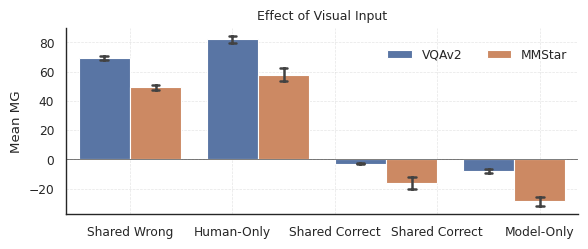

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

fig = plt.figure(figsize=(5.8, 2.4))
sns.set_theme(style="white", context="paper")
palette = sns.color_palette("deep", n_colors=2)

# ---- Panel (a): Mean MG ----
ax = plt.gca()
sns.barplot(
    data=qmg,
    x="cc_quadrant",
    y="MG",
    hue="dataset",
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.12,
    ax=ax
)
# ax.set_title("Effect of Visual Input", fontsize=9)
ax.set_ylabel("Mean MG")
ax.set_xlabel("")
ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    # title="Dataset",
    loc="upper right",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(1, 0.95)
)

ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout(pad=0.4)
plt.show()

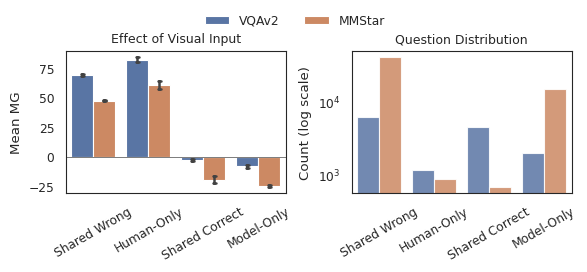

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(
    1, 2,
    figsize=(5.8, 2.4),
    sharex=True
)

palette = sns.color_palette("deep", n_colors=2)

# ---- Panel (a): Mean MG ----
sns.barplot(
    data=qmg,
    x="cc_quadrant",
    y="MG",
    hue="dataset",
    ax=axes[0],
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.12
)
axes[0].set_title("Effect of Visual Input", fontsize=9)
axes[0].set_ylabel("Mean MG")
axes[0].set_xlabel("")
axes[0].axhline(0, color="black", linewidth=0.6, alpha=0.6)

# ---- Panel (b): Counts ----
sns.countplot(
    data=qmg,
    x="cc_quadrant",
    hue="dataset",
    ax=axes[1],
    palette=palette,
    alpha=0.85
)
axes[1].set_yscale("log")
axes[1].set_title("Question Distribution", fontsize=9)
axes[1].set_ylabel("Count (log scale)")
axes[1].set_xlabel("")

# ---- Remove individual legends ----
for ax in axes:
    ax.legend_.remove()
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.tick_params(axis="x", rotation=30)

# ---- Shared legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    # title="Dataset",
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.1)
)

plt.tight_layout(pad=0.4)
plt.savefig("quadrant_mg_unified.pdf", bbox_inches="tight")
plt.show()

<Axes: xlabel='cc_quadrant', ylabel='MG'>

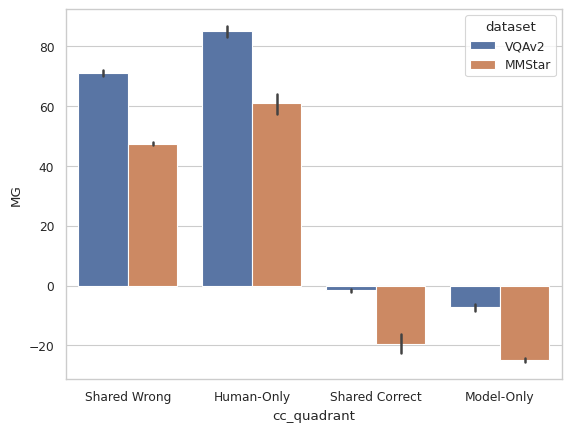

In [37]:

# qmg= qmg[qmg['finetuned'] == "Pretrained"]  
qmg.pivot_table(
    index=['cc_quadrant'] , 
    values=['MG'] , 
    columns=['dataset'] , 
    aggfunc = ['count', 'mean'] ).to_latex('./tables/quadrant-stats.tex', float_format="%.1f") 
sns.barplot(qmg, x='cc_quadrant', y='MG', hue='dataset') 